# Corn Leaf Disease Classification: CRISP-DM Plan

This notebook documents the project from business understanding through data preparation. The task is multiclass image classification with four classes: **Blight**, **Common_Rust**, **Gray_Leaf_Spot**, and **Healthy**.

Project Overview

This project develops a deep-learning image classifier for detecting corn leaf conditions: Blight, Common Rust, Gray Leaf Spot, and Healthy. Following CRISP-DM, the images are cleaned, converted to RGB, resized , and split into training and validation sets. A baseline CNN is compared with a pretrained model such as MobileNetV2 or EfficientNetB0. Performance is measured using accuracy, macro F1-score, per-class recall, precision, and a confusion matrix. The final system is designed to support farmers and agronomists with fast preliminary disease screening, while expert confirmation remains necessary.



## 1. Business Understanding

### Business problem
Corn diseases can reduce yield and quality when they are detected late. Field diagnosis may be slow, inconsistent, or dependent on access to an experienced agronomist. A computer-vision classifier can provide an early screening signal from a photograph of a corn leaf.

### Problem statement
Develop and evaluate an image-classification model that predicts the visible condition of a corn leaf as Blight, Common Rust, Gray Leaf Spot, or Healthy. The model should support rapid, repeatable screening while clearly communicating that predictions are decision support rather than a replacement for expert confirmation.

### Objectives

| Objective | Description | Deliverable |
|---|---|---|
| Classify leaf images | Predict one of four disease/health classes | Trained multiclass classifier |
| Reduce missed disease | Prioritize recall for disease classes, especially in field screening | Per-class recall and confusion matrix |
| Produce trustworthy probabilities | Return confidence scores and flag uncertain cases | Calibrated probabilities or an uncertainty threshold |
| Make the workflow reproducible | Use a documented local path, fixed seed, split, and preprocessing pipeline | Re-runnable notebook |
| Support practical use | Keep inference fast enough for an image-upload workflow | Inference-time and model-size measurements |

### Stakeholders and their interests

| Stakeholder | Interest | What success means for them |
|---|---|---|
| Farmers and field scouts | Fast, accessible disease screening | Correct early alerts and few missed diseased leaves |
| Agronomists and extension officers | A consistent second opinion | Useful explanations, confidence scores, and easy review of uncertain images |
| Agribusiness and crop advisors | Scalable crop-health monitoring | Lower inspection cost and reliable performance across farms |
| Researchers and students | Reproducible experimentation | Transparent data splits, methods, metrics, and limitations |
| Product or deployment team | Maintainable local or web inference | Stable preprocessing, acceptable latency, and versioned models |
| Crop policy and food-security planners | Early visibility of disease patterns | Aggregated, reliable signals without overstating model certainty |

### Value of automation

Automation enables rapid screening of many images, consistent application of the same decision rule, lower manual inspection effort, and earlier escalation to an expert. It is most valuable as a triage layer: high-confidence cases can be prioritized while low-confidence or unusual images are referred for human diagnosis.

### Measures of success

| Success criterion | Target or decision rule |
|---|---|
| Primary model metric | Macro F1 is the main comparison metric because the classes are imbalanced |
| Disease safety | Report recall for each disease class; set a minimum acceptable recall before deployment |
| Healthy/disease confusion | Inspect the confusion matrix and control false negatives for diseased leaves |
| Generalization | Validation performance should remain stable across repeated seeds or a held-out test set |
| Operational usefulness | Measure inference latency, model size, and performance on realistic phone or field images |
| Responsible use | Display confidence and an ``uncertain`` threshold; do not claim expert-level diagnosis without external validation |


## 2. Data Understanding

### Dataset profile and working assumptions

The source dataset is  at `corn_pathology_ai-main/corn_pathology_ai-main/data`, with one folder per class. The audit cell below discovers the path, counts supported image files, checks image dimensions and channels, and creates a reproducible stratified 80/20 split at the file-list level.

| Item | Project value / assumption |
|---|---|
| Class names | Blight, Common_Rust, Gray_Leaf_Spot, Healthy |
| Original image dimensions | Audited from the files; images may have different dimensions |
| Resized dimensions | 224 x 224 pixels, RGB, for a practical transfer-learning baseline |
| Class balance | Imbalanced; Gray_Leaf_Spot is the smallest class |
| Training split | 80% of images, stratified by class |
| Validation split | 20% of images, stratified by class |
| Total source images | 4,188 in the current local dataset audit |
| Expected training images | Computed by the audit cell, approximately 3,350 |
| Expected validation images | Computed by the audit cell, approximately 838 |
| Label type | Single-label multiclass classification |
| Leakage control | Split by image before augmentation; do not place near-duplicate images in both splits |

### Per-class source and training counts

The generated tables distinguish the **source folder count** from the **derived training count**. The current repository has one class-folder dataset rather than pre-created `train` and `validation` folders, so the training counts are created by the stratified split.


2.1 Importing the libraries

In [26]:
#Step 1 — Import the libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import os
import shutil
import hashlib
from pathlib import Path
from collections import Counter
from PIL import Image
from IPython.display import display
import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers


2.2 . Data overview

In [27]:
# Build audit_df before running the Data Understanding cells.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
DATA_CANDIDATES = [
    Path.cwd() / "corn_pathology_ai-main" / "corn_pathology_ai-main" / "data",
    Path.cwd() / "data",
]
DATA_DIR = next((path for path in DATA_CANDIDATES if path.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Dataset folder not found. Check DATA_CANDIDATES.")

records = []
unreadable_images = []

for class_dir in sorted(path for path in DATA_DIR.iterdir() if path.is_dir()):
    for image_path in sorted(class_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        try:
            with Image.open(image_path) as image:
                image.verify()
            with Image.open(image_path) as image:
                records.append({
                    "path": str(image_path),
                    "class_name": class_dir.name,
                    "width": image.width,
                    "height": image.height,
                    "channels": len(image.getbands()),
                    "format": image.format,
                    "color_mode": image.mode,
                })
        except (OSError, ValueError):
            unreadable_images.append(str(image_path))

audit_df = pd.DataFrame(records)
if audit_df.empty:
    raise ValueError(f"No readable images found under {DATA_DIR}")

class_names = sorted(audit_df["class_name"].unique())
print(f"Audited readable images: {len(audit_df):,}")
print(f"Unreadable images: {len(unreadable_images)}")

Audited readable images: 4,188
Unreadable images: 0


In [30]:
print("Total valid images:", len(audit_df))
print("Number of classes:", audit_df["class_name"].nunique())
print("Classes:", sorted(audit_df["class_name"].unique()))

display(audit_df.head())

print("\nDataset information:")
audit_df.info()

Total valid images: 4188
Number of classes: 4
Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


,path,class_name,width,height,channels,format,color_mode
0,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,1000,585,3,JPEG,RGB
1,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,788,371,3,JPEG,RGB
2,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,641,482,3,JPEG,RGB
3,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,300,200,3,JPEG,RGB
4,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,256,256,3,JPEG,RGB



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   path        4188 non-null   str  
 1   class_name  4188 non-null   str  
 2   width       4188 non-null   int64
 3   height      4188 non-null   int64
 4   channels    4188 non-null   int64
 5   format      4188 non-null   str  
 6   color_mode  4188 non-null   str  
dtypes: int64(3), str(4)
memory usage: 229.2 KB


2.3 Image metadata distribution

In [31]:
print("Image formats:")
display(audit_df["format"].value_counts())

print("Color modes:")
display(audit_df["color_mode"].value_counts())

print("Image dimensions:")
display(audit_df[["width", "height"]].describe())

Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64

Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

Image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


2.4  Check missing metadata

In [33]:
missing_values = audit_df.isnull().sum()

print("Missing values by column:")
display(missing_values)

print("Total missing values:", missing_values.sum())

Missing values by column:


path          0
class_name    0
width         0
height        0
channels      0
format        0
color_mode    0
dtype: int64

Total missing values: 0


2.5 Image metadata distribution

In [35]:
print("Image formats:")
display(audit_df["format"].value_counts())

print("Color modes:")
display(audit_df["color_mode"].value_counts())

print("Image dimensions:")
display(audit_df[["width", "height"]].describe())

Image formats:


format
JPEG    4183
PNG        4
MPO        1
Name: count, dtype: int64

Color modes:


color_mode
RGB     4183
RGBA       4
CMYK       1
Name: count, dtype: int64

Image dimensions:


,width,height
count,4188.000000,4188.000000
mean,307.536533,297.906160
std,285.716933,253.138674
min,180.000000,116.000000
25%,256.000000,256.000000
50%,256.000000,256.000000
75%,256.000000,256.000000
max,5184.000000,5184.000000


2.6 Check image quality and file sizes

In [37]:
quality_df["file_size_kb"] = quality_df["path"].apply(
    lambda path: Path(path).stat().st_size / 1024
)

In [38]:
from pathlib import Path

quality_df = audit_df.copy()

quality_df["file_size_kb"] = quality_df["path"].apply(
    lambda path: Path(path).stat().st_size / 1024
)

quality_df["aspect_ratio"] = (
    quality_df["width"] / quality_df["height"]
)

quality_df["image_area"] = (
    quality_df["width"] * quality_df["height"]
)

display(quality_df[
    ["width", "height", "file_size_kb", "aspect_ratio", "image_area"]
].describe().round(2))

,width,height,file_size_kb,aspect_ratio,image_area
count,4188.00,4188.00,4188.00,4188.00,4188.00
mean,307.54,297.91,38.46,1.02,156855.33
std,285.72,253.14,218.26,0.16,811837.53
min,180.00,116.00,3.12,0.29,33872.00
25%,256.00,256.00,11.40,1.00,65536.00
50%,256.00,256.00,13.52,1.00,65536.00
75%,256.00,256.00,15.56,1.00,65536.00
max,5184.00,5184.00,6331.98,3.75,17915904.00


2.6.1 Check unreadable files


In [39]:
print("Unreadable images:", len(unreadable_images))

if unreadable_images:
    display(pd.DataFrame({"unreadable_filepath": unreadable_images}))
else:
    print("No unreadable images detected.")

Unreadable images: 0
No unreadable images detected.


2.7 Class balance

In [45]:
class_counts = (
    audit_df["class_name"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

class_balance_df = pd.DataFrame({
    "class": class_counts.index,
    "image_count": class_counts.values,
    "percentage": (class_counts.values / class_counts.sum() * 100).round(2)
})

display(class_balance_df)

,class,image_count,percentage
0,Blight,1146,27.36
1,Common_Rust,1306,31.18
2,Gray_Leaf_Spot,574,13.71
3,Healthy,1162,27.75


2.8  Visualize class distribution

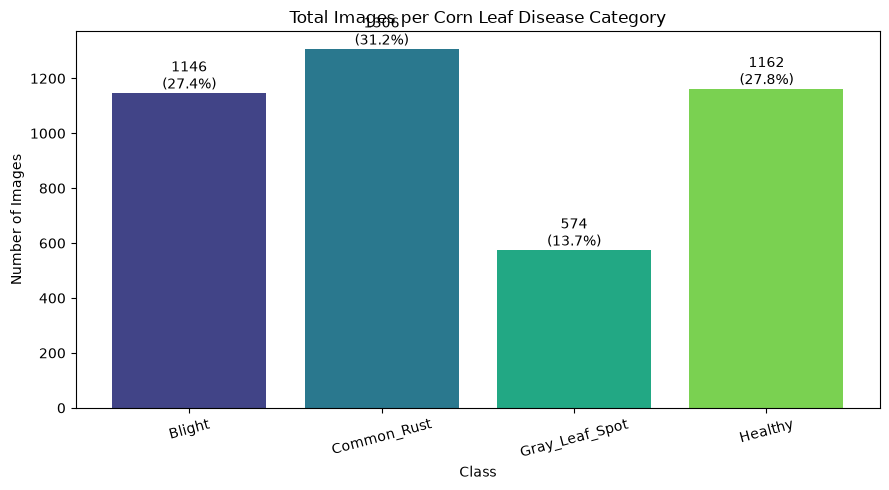

In [46]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    class_balance_df["class"],
    class_balance_df["image_count"],
    color=sns.color_palette("viridis", len(class_names))
)

for bar, count, percentage in zip(
    bars,
    class_balance_df["image_count"],
    class_balance_df["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Total Images per Corn Leaf Disease Category")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

2.9 Diagnose class imbalance

In [47]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest class:", class_counts.idxmax(), largest_class)
print("Smallest class:", class_counts.idxmin(), smallest_class)
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("The dataset is imbalanced. Use class weights or balanced sampling.")
else:
    print("The class distribution is relatively balanced.")

Largest class: Common_Rust 1306
Smallest class: Gray_Leaf_Spot 574
Imbalance ratio: 2.28
The dataset is imbalanced. Use class weights or balanced sampling.


2.9.1 Analyze geometric properties

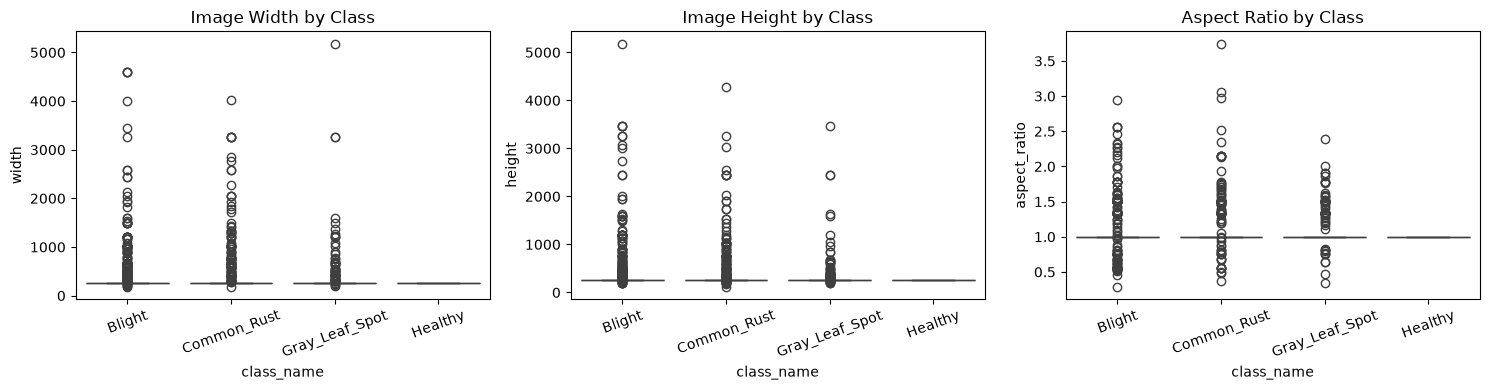

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=quality_df, x="class_name", y="width", ax=axes[0])
axes[0].set_title("Image Width by Class")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=quality_df, x="class_name", y="height", ax=axes[1])
axes[1].set_title("Image Height by Class")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(data=quality_df, x="class_name", y="aspect_ratio", ax=axes[2])
axes[2].set_title("Aspect Ratio by Class")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Find unusual geometric images:

In [50]:
low_resolution_images = quality_df[
    (quality_df["width"] < 100) |
    (quality_df["height"] < 100)
]

extreme_aspect_images = quality_df[
    (quality_df["aspect_ratio"] < 0.5) |
    (quality_df["aspect_ratio"] > 2.0)
]

print("Low-resolution images:", len(low_resolution_images))
print("Extreme-aspect-ratio images:", len(extreme_aspect_images))

display(low_resolution_images.head())
display(extreme_aspect_images.head())

Low-resolution images: 0
Extreme-aspect-ratio images: 30


,path,class_name,width,height,channels,format,color_mode,file_size_kb,aspect_ratio,image_area


,path,class_name,width,height,channels,format,color_mode,file_size_kb,aspect_ratio,image_area
1,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,788,371,3,JPEG,RGB,76.775391,2.123989,292348
14,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,1080,421,3,JPEG,RGB,226.377930,2.565321,454680
25,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,1489,3264,3,JPEG,RGB,1113.178711,0.456189,4860096
122,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,884,3071,3,JPEG,RGB,379.745117,0.287854,2714764
141,c:\Users\admin\Downloads\Capstone Project\corn...,Blight,896,407,3,JPEG,RGB,94.029297,2.201474,364672


2.9.2  Analyze brightness, contrast, saturation, and sharpness

In [53]:
def calculate_visual_features(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize((128, 128))

        rgb = np.asarray(image).astype("float32") / 255.0
        grayscale = np.asarray(image.convert("L")).astype("float32") / 255.0
        hsv = np.asarray(image.convert("HSV")).astype("float32") / 255.0

        horizontal_edges = np.diff(grayscale, axis=1)
        vertical_edges = np.diff(grayscale, axis=0)

        return {
            "brightness": rgb.mean(),
            "contrast": grayscale.std(),
            "saturation": hsv[:, :, 1].mean(),
            "red_mean": rgb[:, :, 0].mean(),
            "green_mean": rgb[:, :, 1].mean(),
            "blue_mean": rgb[:, :, 2].mean(),
            "sharpness_proxy": np.std(
                np.concatenate([
                    horizontal_edges.ravel(),
                    vertical_edges.ravel()
                ])
            )
        }

visual_features = []

for _, row in audit_df.iterrows():
    try:
        features = calculate_visual_features(row["path"])
        features["class_name"] = row["class_name"]
        features["path"] = row["path"]
        visual_features.append(features)
    except (OSError, ValueError):
        pass

visual_df = pd.DataFrame(visual_features)

display(
    visual_df.groupby("class_name")[
        [
            "brightness",
            "contrast",
            "saturation",
            "red_mean",
            "green_mean",
            "blue_mean",
            "sharpness_proxy"
        ]
    ].mean().round(3)
)

,brightness,contrast,saturation,red_mean,green_mean,blue_mean,sharpness_proxy
class_name,,,,,,,
Blight,0.438,0.127,0.286,0.449,0.481,0.383,0.044
Common_Rust,0.343,0.240,0.289,0.359,0.391,0.278,0.058
Gray_Leaf_Spot,0.442,0.140,0.291,0.459,0.487,0.381,0.053
Healthy,0.540,0.125,0.322,0.504,0.640,0.476,0.035


3. DATA PREPARATION

Transform audited images into clean, standardized, leak-free tensors for modeling.

### 3.1 Clean duplicates and encode labels

In [54]:
def calculate_hash(path):
    with open(path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()

prepared_df = audit_df.copy()
prepared_df["image_hash"] = prepared_df["path"].apply(calculate_hash)
hash_label_counts = prepared_df.groupby("image_hash")["class_name"].nunique()
conflicting_hashes = hash_label_counts[hash_label_counts > 1].index
clean_df = prepared_df[~prepared_df["image_hash"].isin(conflicting_hashes)]
clean_df = clean_df.drop_duplicates("image_hash", keep="first").copy()

label_to_id = {name: index for index, name in enumerate(class_names)}
clean_df["label_id"] = clean_df["class_name"].map(label_to_id).astype("int32")
print("Before cleaning:", len(prepared_df))
print("After cleaning:", len(clean_df))
display(clean_df["class_name"].value_counts().reindex(class_names, fill_value=0))

Before cleaning: 4188
After cleaning: 4184


class_name
Blight            1144
Common_Rust       1306
Gray_Leaf_Spot     572
Healthy           1162
Name: count, dtype: int64

### 3.2 Stratified splitting and leakage prevention

In [55]:
train_df, validation_df = train_test_split(
    clean_df, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE,
    stratify=clean_df["label_id"]
)

train_hashes = set(train_df["image_hash"])
validation_hashes = set(validation_df["image_hash"])
print("Exact hash overlap:", len(train_hashes & validation_hashes))

split_summary = pd.DataFrame({
    "training_images": train_df["class_name"].value_counts(),
    "validation_images": validation_df["class_name"].value_counts(),
}).reindex(class_names, fill_value=0)
display(split_summary)

Exact hash overlap: 0


,training_images,validation_images
class_name,,
Blight,915,229
Common_Rust,1045,261
Gray_Leaf_Spot,458,114
Healthy,929,233


### 3.3 RGB conversion, aspect-ratio-preserving resize, batching, and prefetching

In [56]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_prepare_image(path, label_id):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    # Padding preserves aspect ratio and prevents leaf distortion.
    image = tf.image.resize_with_pad(image, IMAGE_SIZE[0], IMAGE_SIZE[1])
    return tf.cast(image, tf.float32), label_id

def create_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((dataframe["path"].values, dataframe["label_id"].values))
    dataset = dataset.map(load_and_prepare_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
validation_ds = create_dataset(validation_df)
sample_images, sample_labels = next(iter(train_ds.take(1)))
print("Batch shape:", sample_images.shape)
print("Pixel range before model normalization:", float(tf.reduce_min(sample_images)), float(tf.reduce_max(sample_images)))

Batch shape: (32, 224, 224, 3)
Pixel range before model normalization: 0.0 255.0


### 3.4 Normalization and training-only augmentation

Keep validation images untouched. Apply normalization inside the model so the same transformation is used during inference.

In [57]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="training_augmentation")

# Basic CNN: use layers.Rescaling(1 / 255.0) after augmentation.
# MobileNetV2: use its 0–255 to -1–1 preprocessing instead.
print("Augmentation layer ready; use it only in the training model path.")

Augmentation layer ready; use it only in the training model path.


### 3.5 Label encoding check

Integer labels work with `SparseCategoricalCrossentropy`. One-hot encoding is optional.

In [58]:
train_one_hot = tf.keras.utils.to_categorical(train_df["label_id"], len(class_names))
validation_one_hot = tf.keras.utils.to_categorical(validation_df["label_id"], len(class_names))
print("Integer label example:", train_df["label_id"].iloc[0])
print("One-hot label example:", train_one_hot[0])
print("Missing values after preparation:", int(clean_df.isnull().sum().sum()))

Integer label example: 3
One-hot label example: [0. 0. 0. 1.]
Missing values after preparation: 0
